# A month of New York yellow cabs, in plain SQL

**3 million taxi trips from January 2023**, queried with SQL only: a 7-day moving average and a week-on-week comparison with `LAG(..., 7)`, hour-by-weekday patterns, ranked pickup zones and routes, airport runs, tipping behaviour and traffic speed by hour built from distance and duration. Python only runs the queries and draws the charts.

**Data:** [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) from the NYC Taxi & Limousine Commission. Run `python build_db.py` once to download January 2023 (about 48 MB, needs `pyarrow`) and turn it into a SQLite database of about 300 MB, then point `TAXI_DB` at that file.

**Reading the data.** A few dozen trips carry timestamps outside January (one is dated 2008), so every query keeps only January 2023. Trips with zero distance, non-positive fares or impossible durations are excluded where they would distort an average. **Cash tips are not recorded** (they are always 0), so tipping is analysed for credit-card trips only.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("TAXI_DB", "taxi.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,payment_types,7
1,ratecodes,6
2,trips,3066766
3,zones,265


## 1. What does the month look like day by day?

Trips per day, a **7-day moving average** from a window frame and a comparison with the same weekday a week earlier using `LAG(trips, 7)`.

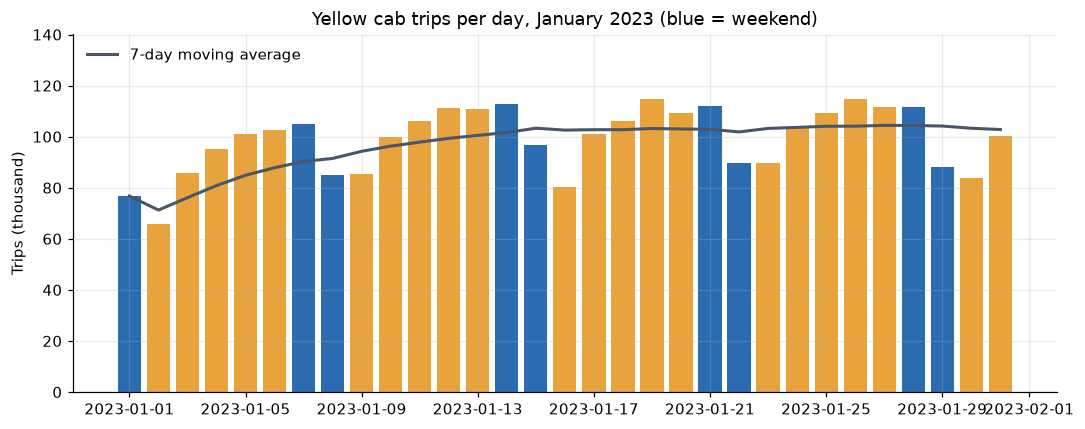

,day,trips,revenue,moving_avg_7d,vs_same_day_last_week_pct
1,2023-01-02,65777,2033445.0,71265.0,NaN
0,2023-01-01,76752,2347475.0,76752.0,NaN
18,2023-01-19,114603,3068877.0,103206.0,2.9
25,2023-01-26,114877,3100412.0,104117.0,0.2


In [3]:
daily = q("""
WITH daily AS (
    SELECT substr(pickup_time, 1, 10) AS day,
           COUNT(*)                   AS trips,
           ROUND(SUM(total_amount))   AS revenue
    FROM trips
    WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01'
    GROUP BY day
)
SELECT day, trips, revenue,
       ROUND(AVG(trips) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)) AS moving_avg_7d,
       ROUND(100.0 * (trips - LAG(trips, 7) OVER (ORDER BY day))
                   / LAG(trips, 7) OVER (ORDER BY day), 1)                            AS vs_same_day_last_week_pct
FROM daily
ORDER BY day
""")

x = pd.to_datetime(daily.day)
weekend = x.dt.dayofweek >= 5
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, daily.trips / 1000, color=[BLUE if w else AMBER for w in weekend])
ax.plot(x, daily.moving_avg_7d / 1000, color="#4a5568", lw=2, label="7-day moving average")
ax.set_ylabel("Trips (thousand)")
ax.set_title("Yellow cab trips per day, January 2023 (blue = weekend)")
ax.set_ylim(0, daily.trips.max() / 1000 * 1.22)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()
daily.sort_values("trips").iloc[[0, 1, -2, -1]]

## 2. When do people take cabs?

`strftime` splits each pickup time into weekday and hour, and a plain `GROUP BY` produces the numbers for a heatmap.

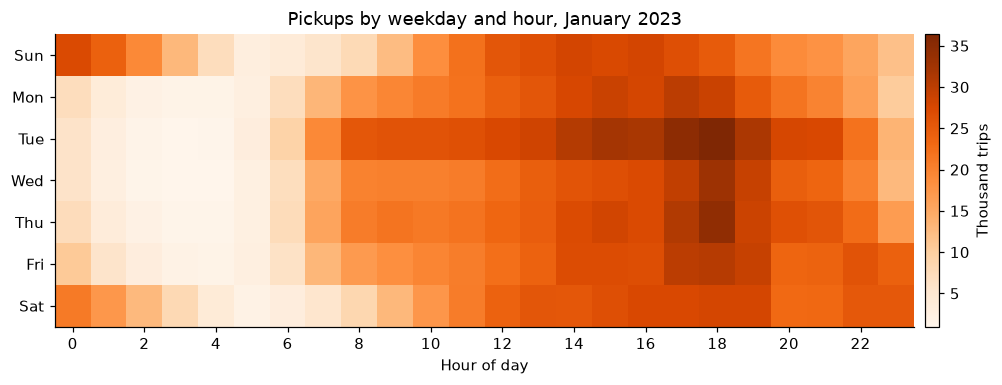

In [4]:
hours = q("""
SELECT CAST(strftime('%w', pickup_time) AS INT) AS weekday,    -- 0 = Sunday
       CAST(strftime('%H', pickup_time) AS INT) AS hour,
       COUNT(*)                                 AS trips
FROM trips
WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01'
GROUP BY weekday, hour
ORDER BY weekday, hour
""")

grid = hours.pivot(index="weekday", columns="hour", values="trips").fillna(0)
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(grid.values / 1000, cmap="Oranges", aspect="auto")
ax.set_yticks(range(7), ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
ax.set_xticks(range(0, 24, 2), range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_title("Pickups by weekday and hour, January 2023")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Thousand trips", pad=0.01)
fig.tight_layout()
plt.show()

## 3. Where do trips start?

Joining the pickup zone ID to the zone lookup gives names, and `RANK()` with a window total gives each zone's rank and share of all trips.

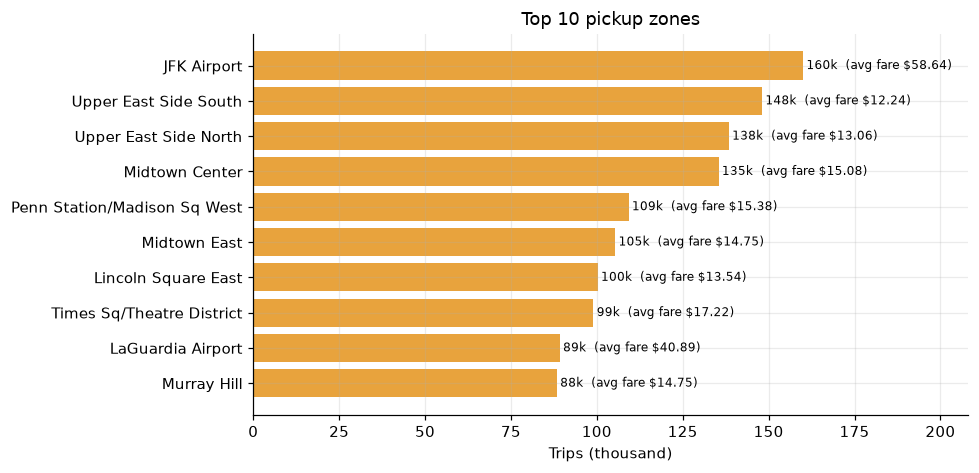

In [5]:
zones = q("""
SELECT RANK() OVER (ORDER BY COUNT(*) DESC)               AS rank,
       z.zone,
       z.borough,
       COUNT(*)                                           AS trips,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
       ROUND(AVG(t.fare_amount), 2)                       AS avg_fare
FROM trips t
JOIN zones z ON z.zone_id = t.pickup_zone_id
WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01'
GROUP BY z.zone_id
ORDER BY trips DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(zones.zone[::-1], zones.trips[::-1] / 1000, color=AMBER)
for y, (v, f) in enumerate(zip(zones.trips[::-1] / 1000, zones.avg_fare[::-1])):
    ax.text(v + 1, y, f"{v:,.0f}k  (avg fare ${f:.2f})", va="center", fontsize=8)
ax.set_xlim(0, zones.trips.max() / 1000 * 1.3)
ax.set_title("Top 10 pickup zones")
ax.set_xlabel("Trips (thousand)")
fig.tight_layout()
plt.show()

## 4. What are the most common routes?

The zone table is joined **twice**, once for the pickup and once for the dropoff, to name both ends of the route. Durations come from `julianday` arithmetic, and implausible trips are filtered out first.

In [6]:
routes = q("""
WITH valid AS (
    SELECT pickup_zone_id, dropoff_zone_id, fare_amount, trip_distance,
           (julianday(dropoff_time) - julianday(pickup_time)) * 1440 AS minutes
    FROM trips
    WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01' AND trip_distance > 0 AND fare_amount > 0
      AND dropoff_time > pickup_time
)
SELECT zp.zone                                AS pickup,
       zd.zone                                AS dropoff,
       COUNT(*)                               AS trips,
       ROUND(AVG(v.trip_distance), 1)         AS avg_miles,
       ROUND(AVG(v.minutes), 1)               AS avg_minutes,
       ROUND(AVG(v.fare_amount), 2)           AS avg_fare
FROM valid v
JOIN zones zp ON zp.zone_id = v.pickup_zone_id
JOIN zones zd ON zd.zone_id = v.dropoff_zone_id
WHERE zp.borough <> 'Unknown' AND zd.borough <> 'Unknown'      -- zones 264 and 265 are not real places
GROUP BY v.pickup_zone_id, v.dropoff_zone_id
ORDER BY trips DESC
LIMIT 10
""")

routes

,pickup,dropoff,trips,avg_miles,avg_minutes,avg_fare
0,Upper East Side South,Upper East Side North,22099,1.1,8.0,8.67
1,Upper East Side North,Upper East Side South,18840,1.1,8.9,9.26
2,Upper East Side North,Upper East Side North,14326,0.7,6.3,6.93
3,Upper East Side South,Upper East Side South,13950,0.7,6.4,7.37
4,Upper East Side South,Midtown Center,9303,1.1,9.1,9.64
5,Midtown Center,Upper East Side South,9242,1.1,9.0,9.55
6,Midtown Center,Upper East Side North,8531,2.0,13.6,13.56
7,Lenox Hill West,Upper East Side North,8240,1.1,7.7,8.70
8,Lincoln Square East,Upper West Side South,8122,1.0,6.5,7.96
9,Upper West Side South,Upper West Side North,8085,0.9,6.0,7.21


## 5. What do airport trips look like?

Conditional logic on the joined zone names splits trips to and from the three airports, with their fare, distance, duration and the tip on credit-card trips (tip as a percentage of the metered fare).

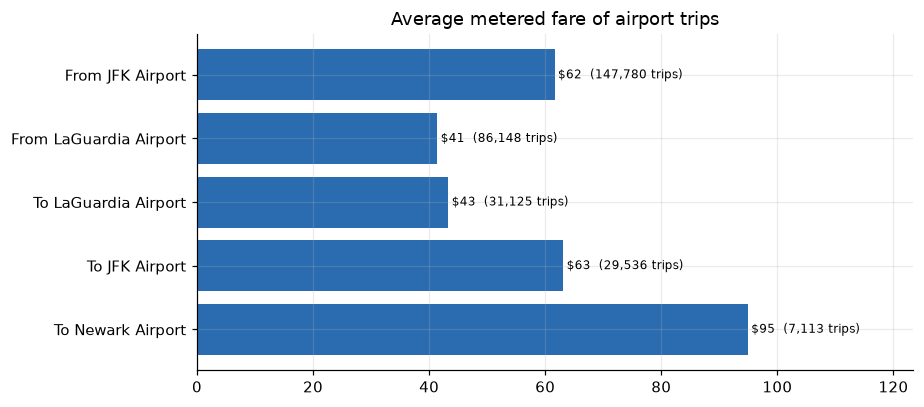

,direction,trips,avg_fare,avg_miles,avg_minutes,avg_tip_pct
0,From JFK Airport,147780,61.6,15.9,38.0,18.6
1,From LaGuardia Airport,86148,41.4,9.7,27.0,24.1
2,To LaGuardia Airport,31125,43.3,10.9,28.0,24.0
3,To JFK Airport,29536,63.1,15.9,42.0,19.6
4,To Newark Airport,7113,94.9,18.7,40.0,19.1


In [7]:
airports = q("""
WITH valid AS (
    SELECT zp.zone AS pickup, zd.zone AS dropoff, t.fare_amount, t.trip_distance, t.tip_amount, t.payment_type,
           (julianday(t.dropoff_time) - julianday(t.pickup_time)) * 1440 AS minutes
    FROM trips t
    JOIN zones zp ON zp.zone_id = t.pickup_zone_id
    JOIN zones zd ON zd.zone_id = t.dropoff_zone_id
    WHERE t.pickup_time >= '2023-01-01' AND t.pickup_time < '2023-02-01' AND t.trip_distance > 0 AND t.fare_amount > 0
      AND t.dropoff_time > t.pickup_time
)
SELECT CASE WHEN dropoff LIKE '%Airport' THEN 'To ' || dropoff ELSE 'From ' || pickup END AS direction,
       COUNT(*)                                       AS trips,
       ROUND(AVG(fare_amount), 1)                     AS avg_fare,
       ROUND(AVG(trip_distance), 1)                   AS avg_miles,
       ROUND(AVG(minutes))                            AS avg_minutes,
       ROUND(100.0 * AVG(CASE WHEN payment_type = 1 AND fare_amount >= 3 AND tip_amount / fare_amount < 1.5
                           THEN tip_amount / fare_amount END), 1) AS avg_tip_pct
FROM valid
WHERE dropoff LIKE '%Airport' OR pickup LIKE '%Airport'
GROUP BY direction
HAVING trips >= 500
ORDER BY trips DESC
""")

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.barh(airports.direction[::-1], airports.avg_fare[::-1], color=BLUE)
for y, (v, n) in enumerate(zip(airports.avg_fare[::-1], airports.trips[::-1])):
    ax.text(v + 0.6, y, f"${v:.0f}  ({n:,} trips)", va="center", fontsize=8)
ax.set_xlim(0, airports.avg_fare.max() * 1.3)
ax.set_title("Average metered fare of airport trips")
fig.tight_layout()
plt.show()
airports

## 6. When do passengers tip, and how much?

Tips are only recorded for credit-card payments, so the query is restricted to them. `AVG(tip_amount / fare_amount)` is the average tip per trip, and averaging the 0/1 expression `tip_amount = 0` gives the share of trips with no tip at all.

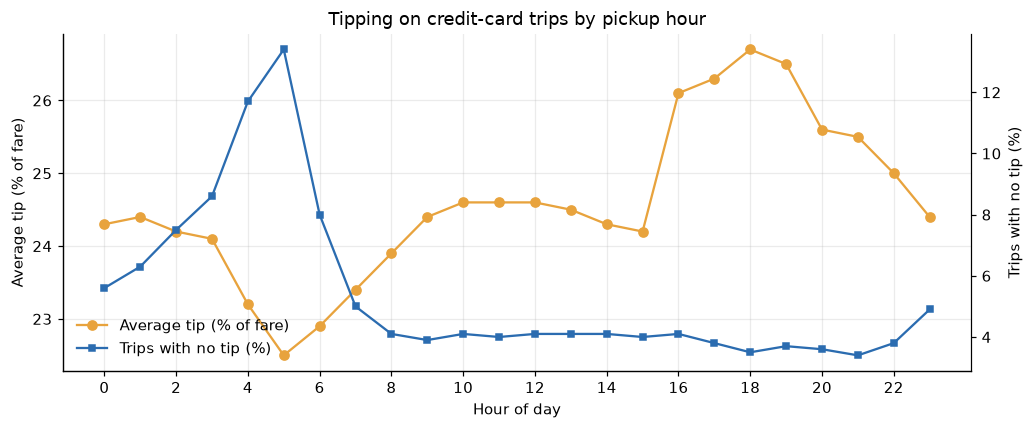

,hour,trips,avg_tip_pct,no_tip_pct
0,0,67422,24.3,5.6
1,1,47830,24.4,6.3
2,2,33201,24.2,7.5
3,3,20917,24.1,8.6
4,4,12185,23.2,11.7
5,5,12004,22.5,13.4
6,6,31806,22.9,8.0
7,7,67423,23.4,5.0
8,8,92546,23.9,4.1
9,9,102233,24.4,3.9


In [8]:
tips = q("""
SELECT CAST(strftime('%H', pickup_time) AS INT)          AS hour,
       COUNT(*)                                          AS trips,
       ROUND(100.0 * AVG(tip_amount / fare_amount), 1)   AS avg_tip_pct,
       ROUND(100.0 * AVG(tip_amount = 0), 1)             AS no_tip_pct
FROM trips
WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01' AND payment_type = 1 AND fare_amount >= 3
  AND tip_amount / fare_amount < 1.5                    -- drop obvious data-entry errors
GROUP BY hour
ORDER BY hour
""")

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(tips.hour, tips.avg_tip_pct, marker="o", color=AMBER, label="Average tip (% of fare)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average tip (% of fare)")
ax.set_xticks(range(0, 24, 2))
ax2 = ax.twinx()
ax2.plot(tips.hour, tips.no_tip_pct, marker="s", ms=4, color=BLUE, label="Trips with no tip (%)")
ax2.set_ylabel("Trips with no tip (%)")
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Tipping on credit-card trips by pickup hour")
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], frameon=False, loc="lower left")
fig.tight_layout()
plt.show()
tips

## 7. How slow is Manhattan traffic?

Average speed is total distance over total time, `SUM(miles) / SUM(hours)`, per pickup hour, split into weekdays and weekends with a `CASE`. Trips under a minute, over three hours or faster than 80 mph are discarded as recording errors.

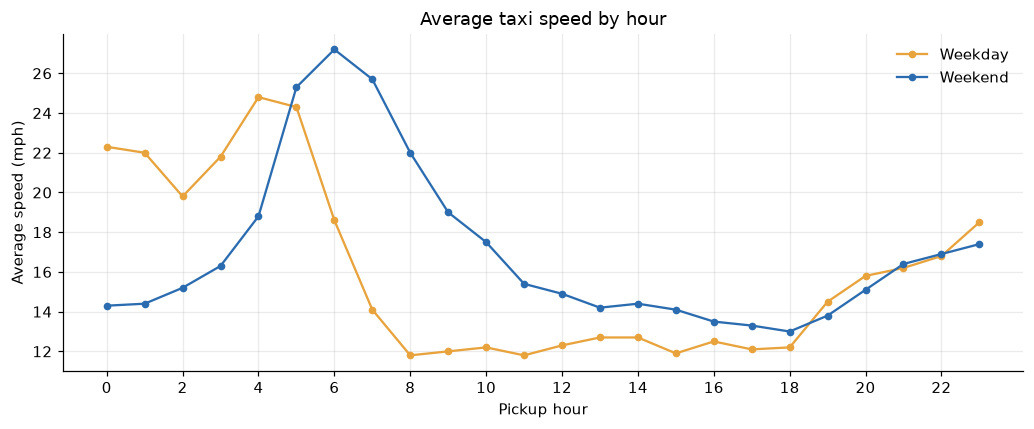

,hour,day_type,trips,avg_mph
11,11,Weekday,109045,11.8
30,6,Weekend,6647,27.2


In [9]:
speed = q("""
WITH valid AS (
    SELECT CAST(strftime('%H', pickup_time) AS INT)                          AS hour,
           CASE WHEN strftime('%w', pickup_time) IN ('0', '6') THEN 'Weekend' ELSE 'Weekday' END AS day_type,
           trip_distance,
           (julianday(dropoff_time) - julianday(pickup_time)) * 24           AS hours
    FROM trips
    WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01' AND trip_distance > 0.2
)
SELECT hour, day_type,
       COUNT(*)                           AS trips,
       ROUND(SUM(trip_distance) / SUM(hours), 1) AS avg_mph
FROM valid
WHERE hours BETWEEN 1.0 / 60 AND 3 AND trip_distance / hours < 80
GROUP BY hour, day_type
ORDER BY day_type, hour
""")

fig, ax = plt.subplots(figsize=(9.5, 4))
for day_type, color in [("Weekday", AMBER), ("Weekend", BLUE)]:
    g = speed[speed.day_type == day_type]
    ax.plot(g.hour, g.avg_mph, marker="o", ms=4, label=day_type, color=color)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Average speed (mph)")
ax.set_title("Average taxi speed by hour")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
speed.sort_values("avg_mph").iloc[[0, -1]]

## 8. Are most trips short hops?

A `CASE` sorts trips into distance buckets and `SUM(COUNT(*)) OVER ()` gives each bucket's share. The fare per mile shows how the meter's starting charge makes short trips expensive per mile.

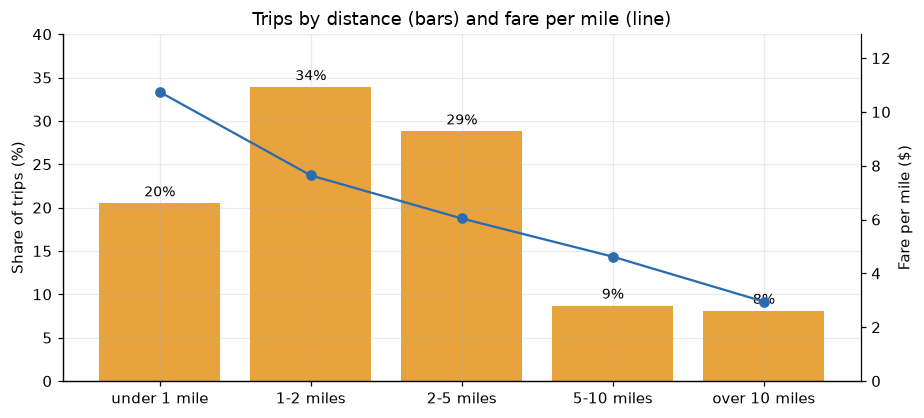

,distance,trips,share_pct,avg_fare,fare_per_mile
0,under 1 mile,614333,20.5,7.44,10.74
1,1-2 miles,1017292,33.9,10.99,7.64
2,2-5 miles,862332,28.8,18.03,6.04
3,5-10 miles,260733,8.7,33.22,4.62
4,over 10 miles,243650,8.1,64.45,2.95


In [10]:
distance = q("""
WITH valid AS (
    SELECT trip_distance, fare_amount,
           CASE WHEN trip_distance < 1  THEN '1  under 1 mile'
                WHEN trip_distance < 2  THEN '2  1-2 miles'
                WHEN trip_distance < 5  THEN '3  2-5 miles'
                WHEN trip_distance < 10 THEN '4  5-10 miles'
                ELSE                         '5  over 10 miles' END AS bucket
    FROM trips
    WHERE pickup_time >= '2023-01-01' AND pickup_time < '2023-02-01' AND trip_distance > 0 AND fare_amount > 0
)
SELECT substr(bucket, 4)                                   AS distance,
       COUNT(*)                                            AS trips,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS share_pct,
       ROUND(AVG(fare_amount), 2)                          AS avg_fare,
       ROUND(SUM(fare_amount) / SUM(trip_distance), 2)     AS fare_per_mile
FROM valid
GROUP BY bucket
ORDER BY bucket
""")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
ax.bar(distance.distance, distance.share_pct, color=AMBER)
for x, v in enumerate(distance.share_pct):
    ax.text(x, v + 0.8, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylabel("Share of trips (%)")
ax.set_ylim(0, distance.share_pct.max() * 1.18)
ax2 = ax.twinx()
ax2.plot(distance.distance, distance.fare_per_mile, color=BLUE, marker="o")
ax2.set_ylabel("Fare per mile ($)")
ax2.set_ylim(0, distance.fare_per_mile.max() * 1.2)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Trips by distance (bars) and fare per mile (line)")
fig.tight_layout()
plt.show()
distance

## What the queries say

- **About 99,000 trips a day, $82.9 million in a month.** January 2023 has 3.07 million yellow-cab trips. The quietest day was Monday 2 January (65,777 trips, the New Year holiday) and the busiest Thursday 26 January (114,877). Weekdays are barely busier than weekends (99,500 against 97,600 trips a day on average).
- **The rush is in the evening.** Tuesday at 6 p.m. is the busiest hour of the week (36,405 trips) and 6 p.m. is the busiest hour overall (215,889 trips over the month), followed by 5, 3 and 4 p.m. The quietest hour is Wednesday at 3 a.m. (973 trips).
- **The biggest pickup zone is an airport.** JFK has 160,024 pickups (5.2% of all trips), ahead of Upper East Side South (148,074) and Upper East Side North (138,391). A JFK pickup averages a $58.64 metered fare against $12-17 for the busiest Manhattan zones.
- **The commonest route is a short hop on the Upper East Side:** 22,099 trips from Upper East Side South to Upper East Side North, 1.1 miles and 8 minutes for an $8.67 fare. Four of the top five routes stay inside or between the two Upper East Side zones.
- **Airport runs are long and pricey.** Trips from JFK average $61.60, 15.9 miles and 38 minutes; from LaGuardia $41.40 and 27 minutes. The 7,113 trips to Newark average $94.90. Credit-card passengers tip between 18.6% and 24.1% of the fare on these trips.
- **Tipping is steady, except for the 5 a.m. crowd.** Across the day credit-card riders tip 22.5-26.7% of the fare on average, and between 3.4% and 13.4% leave nothing. The share of no-tip trips is highest at 5 a.m. (13.4%).
- **Traffic crawls at 12 mph in the daytime.** On weekdays the average speed is 11.8 mph at 8 a.m. and stays between 11.8 and 12.7 mph until the early evening. At night it rises to roughly 20-25 mph, and weekend mornings around 6 a.m. are the fastest of all (27.2 mph).
- **Most trips are short.** 54% of trips are under two miles, and the fare per mile falls from $10.74 for the shortest hops to $2.95 beyond ten miles, because the starting charge is spread over fewer miles.

**Limits:** this is a single winter month; cash tips are not recorded, so tipping covers credit-card trips only; trips with zero distance, non-positive fares or impossible durations were excluded where they would distort an average; a few dozen trips with timestamps outside January were dropped.

**Techniques covered:** `LAG` with an offset, window frames, `RANK`, `SUM() OVER` shares, a self-style double join to a lookup table, `julianday` duration arithmetic, `CASE` buckets and conditional averages.
